# Analiza danych scRNA-seq:

## 1. Konfiguracja środowiska i import bibliotek
Na początku importujemy niezbędne pakiety analityczne. `scanpy` (Single-Cell Analysis in Python) posłuży nam jako główne narzędzie do przetwarzania, redukcji wymiarowości i wizualizacji danych transkryptomicznych.

In [2]:
import os
import scanpy as sc
import pandas as pd
import anndata as ad

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, color_map='viridis', facecolor='white')


## 2. Wczytywanie surowych danych i ekstrakcja metadanych

W tym kroku iterujemy przez foldery zawierające macierze ekspresji dla poszczególnych próbek. 
Nazewnictwo folderów (np. `SC_040522_1G_stim`) zostało zaprojektowane tak, aby zawierało kluczowe informacje eksperymentalne. Automatycznie parsujemy te nazwy, aby przypisać każdej komórce odpowiednie metadane:
* **Dawca / Data pobrania:** (np. 040522)
* **Warunki grawitacyjne:** (1G vs uG)
* **Status stymulacji:** (stim vs unstim)

Wszystkie próbki są następnie łączone w jeden duży obiekt `AnnData`.

In [ ]:
import os
import scanpy as sc
import anndata as ad
from concurrent.futures import ThreadPoolExecutor, as_completed

# Definicja ścieżek do surowych danych
foldery = {
    "SC_040522_1G_stim":   "SC_040522_1G_stim",
    "SC_040522_1G_unstim": "SC_040522_1G_unstim",
    "SC_040522_uG_stim":   "SC_040522_uG_stim",
    "SC_040522_uG_unstim": "SC_040522_uG_unstim",
    "SC_050322_1G_stim":   "SC_050322_1G_stim",
    "SC_050322_1G_unstim": "SC_050322_1G_unstim",
    "SC_050322_uG_stim":   "SC_050322_uG_stim",
    "SC_050322_uG_unstim": "SC_050322_uG_unstim",
}

def wczytaj_probe(args):
    """Funkcja pomocnicza do wczytywania pojedynczej próbki i parsowania metadanych."""
    nazwa, sciezka = args
    adata_tmp = sc.read_10x_mtx(sciezka, var_names='gene_symbols', cache=True)
    
    # Ekstrakcja metadanych z nazwy folderu
    czesci = nazwa.split('_')
    adata_tmp.obs['sample_id']   = nazwa
    adata_tmp.obs['donor']       = czesci[1]       
    adata_tmp.obs['gravity']     = czesci[2]       
    adata_tmp.obs['stimulation'] = czesci[3]       
    
    # Dodanie informacji o płci na podstawie ID dawcy
    adata_tmp.obs['sex'] = 'F' if '040522' in nazwa else 'M'
    
    return nazwa, adata_tmp

print("Rozpoczynam zrównoleglone wczytywanie próbek...")

adatas = {}
with ThreadPoolExecutor(max_workers=12) as executor:
    # Uruchomienie zadań w tle
    futures = {executor.submit(wczytaj_probe, item): item[0] for item in foldery.items()}
    
    # Zbieranie wyników w miarę ich kończenia
    for future in as_completed(futures):
        nazwa, adata_tmp = future.result()
        adatas[nazwa] = adata_tmp
        print(f" -> Pomyślnie wczytano: {nazwa} ({adata_tmp.n_obs} komórek)")

# Sortowanie kluczy, aby zachować pierwotną kolejność zdefiniowaną w słowniku
kolejnosc = list(foldery.keys())

# Konkatenacja wszystkich obiektów w jeden główny zbiór danych
adata = ad.concat(
    [adatas[k] for k in kolejnosc], 
    label="batch", 
    keys=kolejnosc, 
    join="outer", 
    index_unique="-"
)

print("\nZakończono pomyślnie!")
print(f"Główny zbiór danych zawiera: {adata.n_obs} komórek oraz {adata.n_vars} genów.")
display(adata.obs.head())

Rozpoczynam zrównoleglone wczytywanie próbek...
... reading from cache file cache/SC_040522_1G_stim-matrix.h5ad
... reading from cache file cache/SC_040522_uG_stim-matrix.h5ad
... reading from cache file cache/SC_040522_1G_unstim-matrix.h5ad
... reading from cache file cache/SC_040522_uG_unstim-matrix.h5ad
... reading from cache file cache/SC_050322_1G_stim-matrix.h5ad
... reading from cache file cache/SC_050322_1G_unstim-matrix.h5ad
... reading from cache file cache/SC_050322_uG_stim-matrix.h5ad
... reading from cache file cache/SC_050322_uG_unstim-matrix.h5ad
 -> Pomyślnie wczytano: SC_050322_1G_stim (8172 komórek)
 -> Pomyślnie wczytano: SC_050322_uG_stim (3628 komórek)
 -> Pomyślnie wczytano: SC_040522_1G_stim (8225 komórek)
 -> Pomyślnie wczytano: SC_040522_1G_unstim (6986 komórek)
 -> Pomyślnie wczytano: SC_050322_uG_unstim (9060 komórek)
 -> Pomyślnie wczytano: SC_050322_1G_unstim (6318 komórek)
 -> Pomyślnie wczytano: SC_040522_uG_stim (11285 komórek)
 -> Pomyślnie wczytano: SC

,sample_id,donor,gravity,stimulation,sex,batch
AAACCTGAGAGACTTA-1-SC_040522_1G_stim,SC_040522_1G_stim,040522,1G,stim,F,SC_040522_1G_stim
AAACCTGAGCTGAAAT-1-SC_040522_1G_stim,SC_040522_1G_stim,040522,1G,stim,F,SC_040522_1G_stim
AAACCTGAGCTGAACG-1-SC_040522_1G_stim,SC_040522_1G_stim,040522,1G,stim,F,SC_040522_1G_stim
AAACCTGAGGGCACTA-1-SC_040522_1G_stim,SC_040522_1G_stim,040522,1G,stim,F,SC_040522_1G_stim
AAACCTGCACACTGCG-1-SC_040522_1G_stim,SC_040522_1G_stim,040522,1G,stim,F,SC_040522_1G_stim


## 3. Kontrola jakości (QC) i rygorystyczna filtracja

Aby upewnić się, że dalsza analiza opiera się wyłącznie na zdrowych komórkach o wysokiej jakości, przeprowadzamy filtrowanie danych. 
Oznaczamy i analizujemy odsetek genów:
* **Mitochondrialnych (MT):** Wysoki odsetek świadczy o pęknięciu błony komórkowej (komórka martwa/umierająca).
* **Hemoglobiny (HB):** Pozwala usunąć zanieczyszczenia erytrocytami.

**Zastosowane filtry:**
* Minimum 200 genów na komórkę (usunięcie pustych kropli/szumu).
* Maksimum 4000 genów na komórkę (usunięcie potencjalnych dubletów).
* Maksymalnie 10% ekspresji genów mitochondrialnych.
* Maksymalnie 5% ekspresji genów hemoglobiny.

In [4]:
print(f"Liczba komórek przed nałożeniem filtrów QC: {adata.n_obs}")

# Oznaczenie genów mitochondrialnych i kodujących hemoglobinę
adata.var['mt'] = adata.var_names.str.startswith('MT-')
adata.var['hb'] = adata.var_names.str.contains('^HB[AB]', regex=True)

# Obliczenie statystyk kontroli jakości
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'hb'], percent_top=None, inplace=True)

# Aplikacja filtrów ("brutalne cięcie śmieci")
adata = adata[adata.obs['n_genes_by_counts'] > 200, :]
adata = adata[adata.obs['n_genes_by_counts'] < 4000, :] 
adata = adata[adata.obs['pct_counts_mt'] < 10, :]       
adata = adata[adata.obs['pct_counts_hb'] < 5, :].copy() # Użycie .copy() zabezpiecza obiekt w pamięci

print(f"Po rygorystycznym QC zostaje: {adata.n_obs} zdrowych komórek.")

Liczba komórek przed nałożeniem filtrów QC: 66323
Po rygorystycznym QC zostaje: 60598 zdrowych komórek.


## 4. Normalizacja, Logarytmizacja i PCA

Po usunięciu zanieczyszczeń, dane surowe muszą zostać znormalizowane, aby zniwelować różnice w głębokości sekwencjonowania pomiędzy poszczególnymi komórkami. 
* **Normalizacja globalna:** Skaluje całkowitą liczbę zliczeń w każdej komórce do 10 000.
* **Transformacja logarytmiczna:** Zmniejsza wpływ genów o skrajnie wysokiej ekspresji (log1p).
* **Wybór genów o wysokiej zmienności (HVG):** Skupiamy się na genach, które niosą najwięcej informacji biologicznej.
* **Analiza Głównych Składowych (PCA):** Redukcja wymiarowości w oparciu o wyselekcjonowane geny zmienne.

In [5]:
print("Rozpoczęcie globalnej normalizacji danych (target sum = 10,000)...")
sc.pp.normalize_total(adata, target_sum=1e4)

print("Transformacja logarytmiczna (log1p)...")
sc.pp.log1p(adata)

print("Identyfikacja genów o wysokiej zmienności (Highly Variable Genes)...")
sc.pp.highly_variable_genes(
    adata, 
    min_mean=0.0125, 
    max_mean=3, 
    min_disp=0.5
)

print("Obliczanie Analizy Głównych Składowych (PCA)...")
# Użycie solvera 'arpack' do szybkiej i wydajnej redukcji wymiarowości
sc.tl.pca(adata, svd_solver='arpack')

print("Zakończono etap normalizacji i redukcji PCA")

Rozpoczęcie globalnej normalizacji danych (target sum = 10,000)...
normalizing counts per cell
    finished (0:00:00)
Transformacja logarytmiczna (log1p)...
Identyfikacja genów o wysokiej zmienności (Highly Variable Genes)...
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Obliczanie Analizy Głównych Składowych (PCA)...
computing PCA
    with n_comps=50
    finished (0:00:11)
Zakończono etap normalizacji i redukcji PCA


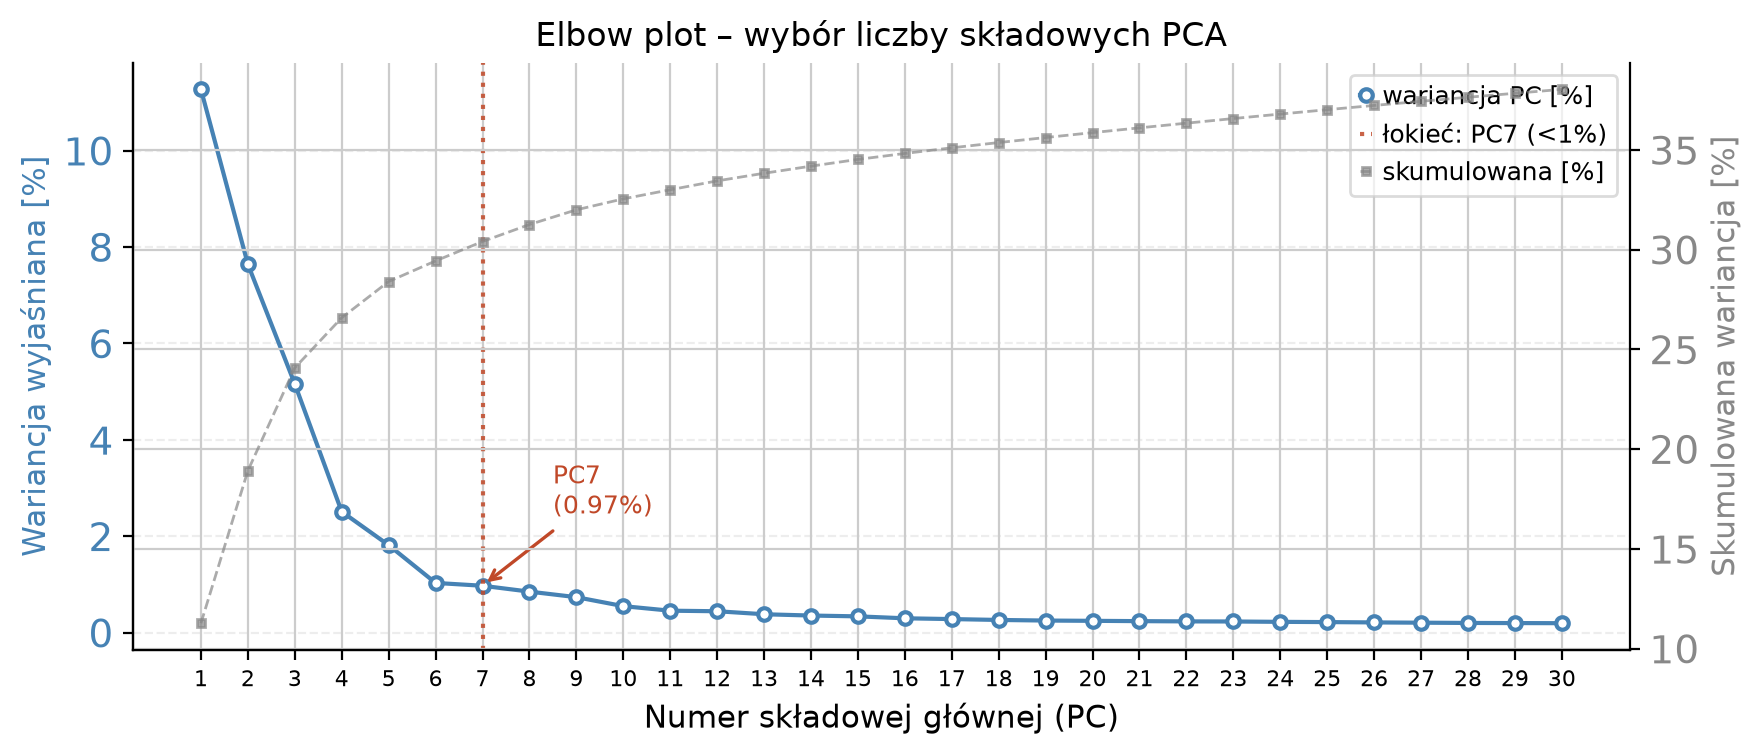

Zapisano: ./figures/elbow_plot_PCA.png

Automatycznie wykryty łokieć: PC7
Skumulowana wariancja PC1–7: 30.4%
Skumulowana wariancja PC1–50: 41.5%


In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

var_ratio = adata.uns['pca']['variance_ratio'] * 100
n_pcs_show = 30
x = np.arange(1, n_pcs_show + 1)
y = var_ratio[:n_pcs_show]
y_cum = np.cumsum(var_ratio[:n_pcs_show])

elbow_pc = next((i+1 for i in range(1, len(y))
                 if y[i] < 1.0), None)

fig, ax1 = plt.subplots(figsize=(9, 4))

ax1.plot(x, y, marker='o', markersize=4.5, linewidth=1.5,
         color='steelblue', markerfacecolor='white',
         markeredgewidth=1.5, label='wariancja PC [%]')

ax1.set_xlabel('Numer składowej głównej (PC)', fontsize=11)
ax1.set_ylabel('Wariancja wyjaśniana [%]', fontsize=11, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(x, fontsize=8)
ax1.grid(axis='y', linestyle='--', alpha=0.35)
ax1.spines[['top', 'right']].set_visible(False)

ax2 = ax1.twinx()
ax2.plot(x, y_cum, marker='s', markersize=3, linewidth=1,
         color='#888', linestyle='--', alpha=0.7,
         label='skumulowana [%]')
ax2.set_ylabel('Skumulowana wariancja [%]', fontsize=11, color='#888')
ax2.tick_params(axis='y', labelcolor='#888')
ax2.spines[['top']].set_visible(False)

if elbow_pc:
    ax1.axvline(x=elbow_pc, color='#C04828', linewidth=1.5,
                linestyle=':', alpha=0.85,
                label=f'łokieć: PC{elbow_pc} (<1%)')
    ax1.annotate(f'PC{elbow_pc}\n({y[elbow_pc-1]:.2f}%)',
                 xy=(elbow_pc, y[elbow_pc-1]),
                 xytext=(elbow_pc + 1.5, y[elbow_pc-1] + 1.5),
                 fontsize=9, color='#C04828',
                 arrowprops=dict(arrowstyle='->', color='#C04828',
                                 lw=1.2))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           fontsize=9, loc='upper right', framealpha=0.7)

ax1.set_title('Elbow plot – wybór liczby składowych PCA', fontsize=12)
plt.tight_layout()

sciezka = './figures/elbow_plot_PCA.png'
plt.savefig(sciezka, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Zapisano: {sciezka}")
print(f"Automatycznie wykryty łokieć: PC{elbow_pc}")
print(f"Skumulowana wariancja PC1–{elbow_pc}: {y_cum[elbow_pc-1]:.1f}%")
print(f"Skumulowana wariancja PC1–50: {np.cumsum(var_ratio)[49]:.1f}%")

## 5. Automatyczna adnotacja typów komórek (CellTypist)

Zamiast ręcznego mapowania klastrów na podstawie ekspresji genów markerowych, wykorzystujemy uczenie maszynowe do automatycznej identyfikacji subpopulacji komórkowych. 
Wykorzystano narzędzie `CellTypist` oraz pre-trenowany model referencyjny `Immune_All_Low` (dostosowany do komórek układu odpornościowego, np. PBMC). 

*Uwaga: Algorytm do poprawnego działania wymaga danych poddanych normalizacji globalnej oraz transformacji logarytmicznej, co zostało wykonane w poprzednim kroku (QC i Normalizacja).*

In [ ]:
import celltypist
from celltypist import models
import os

os.makedirs('./figures', exist_ok=True)

print("Pobieranie modelu referencyjnego (Immune_All_Low)...")
models.download_models(force_update=False)
model = models.Model.load(model='Immune_All_Low.pkl')

print("Rozpoczynam adnotację (CellTypist)...")
# celltypist nie modyfikuje adata, nie trzeba robić .copy()
predictions = celltypist.annotate(adata, model=model)

adata.obs['cell_type'] = predictions.predicted_labels['predicted_labels']

if 'conf_score' in predictions.predicted_labels.columns:
    adata.obs['cell_type_conf'] = predictions.predicted_labels['conf_score']

if 'majority_voting' in predictions.predicted_labels.columns:
    adata.obs['cell_type_majority'] = predictions.predicted_labels['majority_voting']

sciezka_csv = './figures/anotacje_celltypist.csv'
adata.obs[['sample_id', 'cell_type']].to_csv(sciezka_csv)
print(f"Zapisano tabelę: {sciezka_csv}\n")

print("Zestawienie zidentyfikowanych typów komórek:")
display(adata.obs['cell_type'].value_counts().to_frame(name='Liczba komórek'))

/home/anastasiya/miniconda3/envs/licencjat/lib/python3.11/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv
📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json


Pobieranie modelu referencyjnego (Immune_All_Low)...


📚 Total models in list: 61
📂 Storing models in /home/anastasiya/.celltypist/data/models
💾 Downloading model [1/61]: Immune_All_Low.pkl
💾 Downloading model [2/61]: Immune_All_High.pkl
💾 Downloading model [3/61]: Adult_COVID19_PBMC.pkl
💾 Downloading model [4/61]: Adult_CynomolgusMacaque_Hippocampus.pkl
💾 Downloading model [5/61]: Adult_Human_MTG.pkl
💾 Downloading model [6/61]: Adult_Human_PancreaticIslet.pkl
💾 Downloading model [7/61]: Adult_Human_PrefrontalCortex.pkl
💾 Downloading model [8/61]: Adult_Human_Skin.pkl
💾 Downloading model [9/61]: Adult_Human_Vascular.pkl
💾 Downloading model [10/61]: Adult_Mouse_Gut.pkl
💾 Downloading model [11/61]: Adult_Mouse_OlfactoryBulb.pkl
💾 Downloading model [12/61]: Adult_Pig_Hippocampus.pkl
💾 Downloading model [13/61]: Adult_RhesusMacaque_Hippocampus.pkl
💾 Downloading model [14/61]: Adult_cHSPCs_Illumina.pkl
💾 Downloading model [15/61]: Adult_cHSPCs_Ultima.pkl
💾 Downloading model [16/61]: Autopsy_COVID19_Lung.pkl
💾 Downloading model [17/61]: COVID19_

Rozpoczynam adnotację (CellTypist)...


🧬 6147 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


Zapisano tabelę: ./figures/anotacje_celltypist.csv

Zestawienie zidentyfikowanych typów komórek:


,Liczba komórek
cell_type,
Tcm/Naive helper T cells,17110
Tem/Temra cytotoxic T cells,7372
CD16+ NK cells,4314
Tem/Trm cytotoxic T cells,4142
Tcm/Naive cytotoxic T cells,3000
...,...
Granulocytes,1
Fibroblasts,1
Pro-B cells,1


## Zapis punktu kontrolnego (Checkpoint)

Zapisujemy przetworzony obiekt `AnnData` do pliku `.h5ad`. Dzięki temu w przyszłości możemy rozpocząć pracę bezpośrednio od tego miejsca, omijając czasochłonne etapy wczytywania plików surowych, kontroli jakości oraz redukcji wymiarowości.

In [7]:
import os

katalog_roboczy = os.getcwd()
katalog_checkpointow = os.path.join(katalog_roboczy, 'data_checkpoints')
os.makedirs(katalog_checkpointow, exist_ok=True)

sciezka_zapisu = os.path.join(katalog_checkpointow, 'adata_po_QC_i_PCA.h5ad')
print(f"Zapisuję do: {sciezka_zapisu}")

adata.write_h5ad(sciezka_zapisu)

if os.path.exists(sciezka_zapisu):
    rozmiar_mb = os.path.getsize(sciezka_zapisu) / (1024 * 1024)
    print(f"SUKCES! Rozmiar pliku: {rozmiar_mb:.2f} MB")
else:
    print("BŁĄD: Zapis się nie powiódł!")

... storing 'sample_id' as categorical
... storing 'donor' as categorical
... storing 'gravity' as categorical
... storing 'stimulation' as categorical
... storing 'sex' as categorical


Zapisuję do: /home/anastasiya/licencjat_code/data_checkpoints/adata_po_QC_i_PCA.h5ad
SUKCES! Rozmiar pliku: 866.44 MB


In [ ]:
import scanpy as sc
import celltypist
from celltypist import models
import os

print("1. Wczytywanie pliku bazowego...")
adata = sc.read_h5ad('data_checkpoints/adata_po_QC_i_PCA.h5ad')
print(f"Wczytano: {adata.n_obs} komórek.")

print("2. Adnotacja (CellTypist)...")
models.download_models(force_update=False)
model = models.Model.load(model='Immune_All_Low.pkl')
predictions = celltypist.annotate(adata, model=model)
adata.obs['cell_type'] = predictions.predicted_labels['predicted_labels']

print("3. Obliczanie grafu sąsiedztwa i UMAP...")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40, use_rep='X_pca')
sc.tl.umap(adata)

print("4. Dodawanie kolumny 'warunek'...")
adata.obs['warunek'] = adata.obs['gravity'].astype(str) + '_' + adata.obs['stimulation'].astype(str)

print("5. Zapisywanie...")
os.makedirs('data_checkpoints', exist_ok=True)
sciezka_zapisu = 'data_checkpoints/dane_po_anotacji_z_umap.h5ad'
adata.write_h5ad(sciezka_zapisu)
print(f"SUKCES! Zapisano: {sciezka_zapisu}")

1. Wczytywanie pliku bazowego...


📂 Storing models in /home/anastasiya/.celltypist/data/models
⏩ Skipping [1/61]: Immune_All_Low.pkl (file exists)
⏩ Skipping [2/61]: Immune_All_High.pkl (file exists)
⏩ Skipping [3/61]: Adult_COVID19_PBMC.pkl (file exists)
⏩ Skipping [4/61]: Adult_CynomolgusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [5/61]: Adult_Human_MTG.pkl (file exists)
⏩ Skipping [6/61]: Adult_Human_PancreaticIslet.pkl (file exists)
⏩ Skipping [7/61]: Adult_Human_PrefrontalCortex.pkl (file exists)
⏩ Skipping [8/61]: Adult_Human_Skin.pkl (file exists)
⏩ Skipping [9/61]: Adult_Human_Vascular.pkl (file exists)
⏩ Skipping [10/61]: Adult_Mouse_Gut.pkl (file exists)
⏩ Skipping [11/61]: Adult_Mouse_OlfactoryBulb.pkl (file exists)
⏩ Skipping [12/61]: Adult_Pig_Hippocampus.pkl (file exists)
⏩ Skipping [13/61]: Adult_RhesusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [14/61]: Adult_cHSPCs_Illumina.pkl (file exists)
⏩ Skipping [15/61]: Adult_cHSPCs_Ultima.pkl (file exists)
⏩ Skipping [16/61]: Autopsy_COVID19_Lung.pk

Wczytano: 60598 komórek.

2. Adnotacja (CellTypist)...


🧬 6147 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!



3. Obliczanie grafu sąsiedztwa i UMAP...
computing neighbors


/home/anastasiya/miniconda3/envs/licencjat/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:26)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:34)


... storing 'warunek' as categorical



4. Dodawanie kolumny 'warunek'...

5. Zapisywanie...
SUKCES! Zapisano: data_checkpoints/dane_po_anotacji_z_umap.h5ad
